# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# TODO: chọn device ("cuda" nếu có GPU, ngược lại "cpu"; trên Mac có thể "mps"); in torch.__version__ và tên GPU
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("PyTorch:", torch.__version__, "Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
# TODO: os.makedirs cho f"{OUT_DIR}/figures" và f"{OUT_DIR}/results"

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.14.1+cpu Device: cpu


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.


Gi? l? cu?i d? s? m?u nh? h?n batch size: kh?ng b? m?u, kh?ng th?m m?u. V?i batch size 512, l? cu?i c? 135 m?u. Mean/std ch? t?nh t? train sau khi t?ch validation, r?i d?ng chung cho val v? eval.


In [2]:
from pathlib import Path
processed_dir = Path(REPO_ROOT) / "data" / "processed"
if not all((processed_dir / name).exists() for name in ("train.npz", "eval.npz")):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed_dir))

numeric = data["X_tr"][:, :10].to(torch.float64)
means = numeric.mean(dim=0)
stds = numeric.std(dim=0, correction=0)
print("Mean of 10 numeric columns:", means.cpu().numpy())
print("Std of 10 numeric columns:", stds.cpu().numpy())
assert torch.allclose(means, torch.zeros_like(means), atol=1e-5, rtol=0)
assert torch.allclose(stds, torch.ones_like(stds), atol=1e-5, rtol=0)

batch_size = 512
generator = torch.Generator(device=device).manual_seed(42)
n_seen = n_batches = last_batch_size = 0
for xb, yb in iterate_batches(data["X_tr"], data["y_tr"], batch_size, generator=generator):
    assert xb.shape == (len(yb), 54)
    n_seen += len(yb)
    n_batches += 1
    last_batch_size = len(yb)
assert n_seen == len(data["X_tr"])
assert last_batch_size == (n_seen - 1) % batch_size + 1
print(f"Batches: {n_batches}; samples: {n_seen}; last batch: {last_batch_size}")


X_tr: (371847, 54), y_tr: (371847,)
X_val: (92962, 54), y_val: (92962,)
X_eval: (116203, 54), y_eval: (116203,)
Majority class (from train): 1; val accuracy: 0.487597
Mean of 10 numeric columns: [-6.73883753e-11 -1.46488192e-10 -3.42966406e-09  3.00766271e-10
 -1.53744727e-09 -1.02212679e-10 -1.56614732e-09 -1.91377376e-09
 -1.41332503e-09  6.88944764e-10]
Std of 10 numeric columns: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Batches: 727; samples: 371847; last batch: 135


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [ ]:
# TODO 1: Tạo model và kiểm tra số tham số (các giá trị model sẽ học).
# Cố định cách sinh số ngẫu nhiên để dễ chạy lại và so sánh kết quả.
torch.manual_seed(42)
# Hai lớp ẩn có 256 và 128 nơ-ron; không tắt ngẫu nhiên nơ-ron (dropout=0).
# He đặt trọng số ban đầu phù hợp với ReLU; .to(device) đưa model lên CPU/GPU đã chọn.
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
# assert dừng chương trình nếu số tham số không đúng 47 879.
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print("Parameters:", count_params(model))

# TODO 2: Cho dữ liệu thử đi qua từng lớp và kiểm tra kích thước.
# Chuyển sang chế độ kiểm tra; các lớp Dropout (nếu có) sẽ không tắt nơ-ron.
model.eval()
# Tạo 8 mẫu ngẫu nhiên, mỗi mẫu có 54 đặc trưng; dùng cùng thiết bị với model.
x = torch.randn(8, 54, device=device)
# Linear đổi số đặc trưng; ReLU chỉ đổi giá trị nên giữ nguyên kích thước.
expected_shapes = [(8, 256), (8, 256), (8, 128), (8, 128), (8, 7)]
print("Input:", tuple(x.shape))
# Không cần tính gradient (mức ảnh hưởng của tham số tới loss) khi chỉ kiểm tra đầu ra.
with torch.no_grad():
    # h giữ đầu ra hiện tại và được truyền tiếp cho lớp sau.
    h = x
    # zip ghép mỗi lớp với kích thước mong đợi; enumerate thêm số thứ tự lớp.
    for i, (layer, expected) in enumerate(zip(model.net, expected_shapes)):
        # Đưa dữ liệu qua đúng một lớp.
        h = layer(h)
        print(f"Layer {i}: {layer} -> {tuple(h.shape)}")
        assert tuple(h.shape) == expected
    # logits là 7 điểm số cho mỗi mẫu, chưa chuyển thành xác suất.
    # Chạy cả model để đối chiếu với cách chạy từng lớp ở trên.
    logits = model(x)
assert len(model.net) == len(expected_shapes)
# 8 mẫu đầu vào phải cho 8 hàng đầu ra, mỗi hàng gồm 7 điểm số.
assert logits.shape == (8, 7)
# Hai cách chạy phải cho kết quả gần bằng nhau (cho phép sai số rất nhỏ).
assert torch.allclose(h, logits)


Parameters: 47879
Input: (8, 54)
Layer 0: Linear(in_features=54, out_features=256, bias=True) -> (8, 256)
Layer 1: ReLU() -> (8, 256)
Layer 2: Linear(in_features=256, out_features=128, bias=True) -> (8, 128)
Layer 3: ReLU() -> (8, 128)
Layer 4: Linear(in_features=128, out_features=7, bias=True) -> (8, 7)


In [ ]:
# TODO 3: Đo loss (mức sai của dự đoán) trên val trước khi cập nhật trọng số.
import math
import torch.nn.functional as F

# Dùng chế độ kiểm tra để đo loss ổn định, không bật Dropout.
model.eval()
# Cộng loss của tất cả mẫu rồi chia số mẫu để lấy trung bình toàn bộ val.
val_loss_sum = 0.0
# Chỉ đo kết quả, không cần lưu thông tin để tính gradient.
with torch.no_grad():
    # Chia val thành các lô tối đa 8192 mẫu để giảm bộ nhớ cần dùng.
    # xb là đặc trưng của lô, yb là nhãn đúng; không cần xáo trộn khi đo loss.
    for xb, yb in iterate_batches(data["X_val"], data["y_val"], 8192, shuffle=False):
        # cross_entropy nhận điểm số thô và nhãn đúng; không thêm softmax trước nó.
        # reduction="sum" cộng loss trong lô; .item() lấy số Python từ tensor.
        val_loss_sum += F.cross_entropy(model(xb), yb, reduction="sum").item()
# Chia tổng loss cho tổng số mẫu; lô cuối nhỏ hơn vẫn được tính đúng.
step0_loss = val_loss_sum / len(data["y_val"])
# log là ln (logarit tự nhiên); ln(7) là loss khi mỗi lớp có xác suất 1/7.
uniform_loss = math.log(7)
print(f"Step-0 val loss: {step0_loss:.6f}")
print(f"ln(7): {uniform_loss:.6f}; difference: {step0_loss - uniform_loss:+.6f}")
# Kiểm tra loss là số hữu hạn, không phải NaN (không xác định) hay vô cực.
assert math.isfinite(step0_loss)
# He tạo các điểm số ngẫu nhiên khác nhau, nên loss ban đầu có thể lệch ln(7).


Step-0 val loss: 2.377572
ln(7): 1.945910; difference: +0.431662


20 samples: loss 2.166669 -> 0.00000725
20 samples: accuracy = 100.0%


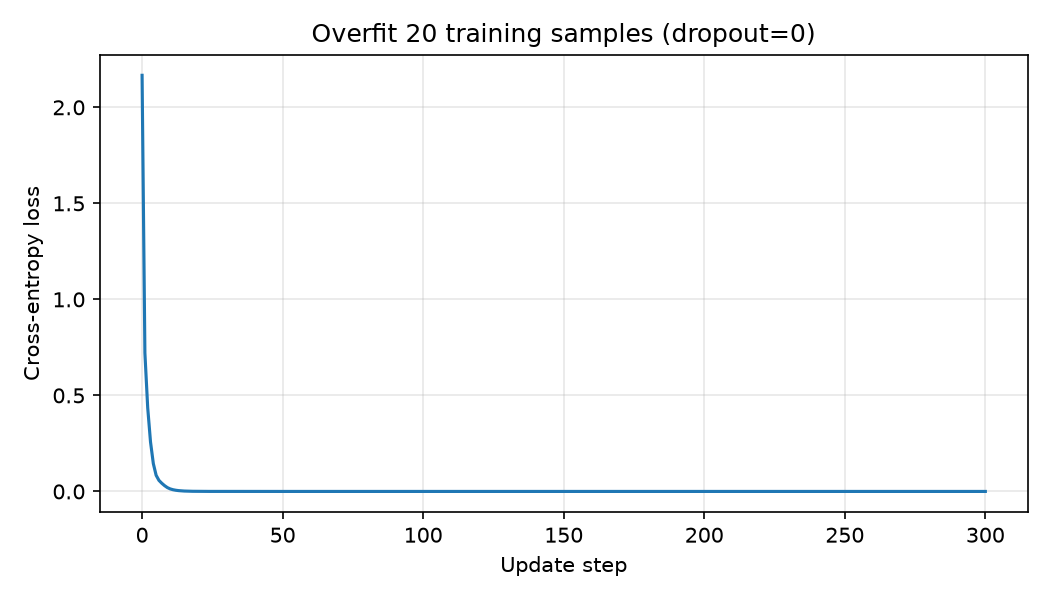

In [ ]:
# TODO 4: Cho model học đi học lại 20 mẫu train để kiểm tra có học được không.
# Dùng model riêng để model ban đầu vẫn chưa được cập nhật trọng số.
import matplotlib.pyplot as plt
from pathlib import Path

# Cố định số ngẫu nhiên cho lần thử học thuộc này.
torch.manual_seed(42)
# Tắt Dropout để model dễ học thuộc toàn bộ 20 mẫu.
small_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
# Adam là cách cập nhật trọng số; lr=0.01 điều chỉnh mức thay đổi mỗi bước.
# weight_decay=0 tắt phần phạt trọng số lớn để thử học thuộc dễ hơn.
optimizer = torch.optim.Adam(small_model.parameters(), lr=0.01, weight_decay=0.0)
# Xáo trộn chỉ số các mẫu train rồi lấy 20 chỉ số đầu; không lấy mẫu từ val/eval.
indices = torch.randperm(len(data["X_tr"]), device=device)[:20]
# Lấy đặc trưng và nhãn theo cùng chỉ số để không ghép nhầm mẫu với nhãn.
x_small, y_small = data["X_tr"][indices], data["y_tr"][indices]
assert len(y_small) == 20
# Bật chế độ huấn luyện; Dropout vẫn tắt vì đã đặt bằng 0.
small_model.train()
with torch.no_grad():
    # Lưu loss trước lần cập nhật đầu tiên làm mốc so sánh.
    small_losses = [F.cross_entropy(small_model(x_small), y_small).item()]
# Mỗi bước đều học lại đúng 20 mẫu này; mục tiêu là học thuộc chúng.
for step in range(300):
    # Xoá gradient cũ để không cộng dồn từ bước trước.
    optimizer.zero_grad(set_to_none=True)
    # Dự đoán 20 mẫu và tính mức sai so với nhãn đúng.
    loss = F.cross_entropy(small_model(x_small), y_small)
    assert torch.isfinite(loss).item(), f"Non-finite loss at step {step}"
    # Tính gradient: mỗi tham số ảnh hưởng đến loss như thế nào.
    loss.backward()
    # Dùng gradient vừa tính để cập nhật trọng số nhằm giảm loss.
    optimizer.step()
    with torch.no_grad():
        # Đo lại loss SAU cập nhật và lưu để vẽ đường cong.
        small_losses.append(F.cross_entropy(small_model(x_small), y_small).item())

# Kết thúc học, chuyển sang chế độ kiểm tra kết quả.
small_model.eval()
with torch.no_grad():
    small_logits = small_model(x_small)
    final_small_loss = F.cross_entropy(small_logits, y_small).item()
    # argmax chọn lớp có điểm cao nhất; so với nhãn đúng rồi lấy tỉ lệ dự đoán đúng.
    small_accuracy = (small_logits.argmax(dim=1) == y_small).float().mean().item()
print(f"20 samples: loss {small_losses[0]:.6f} -> {final_small_loss:.8f}")
print(f"20 samples: accuracy = {small_accuracy:.1%}")
# Quy ước "gần 0" ở phép thử này là loss < 0.01.
assert final_small_loss < 0.01, "The model has not memorized the 20 samples yet"
# Yêu cầu dự đoán đúng cả 20 mẫu, tức accuracy = 100%.
assert small_accuracy == 1.0

# Tạo biểu đồ: trục ngang là số bước cập nhật, trục dọc là loss.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(small_losses)), small_losses)
ax.set(xlabel="Update step", ylabel="Cross-entropy loss", title="Overfit 20 training samples (dropout=0)")
ax.grid(alpha=0.3)
fig.tight_layout()
# Lưu ảnh vào thư mục figures của bài nộp.
figure_path = Path(OUT_DIR) / "figures" / "part1_overfit20.png"
# Tạo thư mục nếu chưa có; exist_ok=True cho phép thư mục đã tồn tại.
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
# Hiển thị biểu đồ ngay dưới ô notebook.
plt.show()


In [ ]:
# TODO 5: Kiểm tra gradient trên model ban đầu, chưa cập nhật trọng số.
# Chuẩn gradient là một số đo độ lớn tổng thể của gradient trong một nhóm tham số.
model.train()
# Xoá gradient để phép kiểm tra chỉ phản ánh lần backward này.
model.zero_grad(set_to_none=True)
# Dùng 20 mẫu có nhãn thật để tính loss trên model ban đầu.
grad_loss = F.cross_entropy(model(x_small), y_small)
# Tính gradient và lưu vào thuộc tính .grad của từng tham số.
grad_loss.backward()
grad_norms = {}
# Duyệt từng nhóm trọng số (weight) và giá trị cộng thêm (bias) kèm tên.
for name, parameter in model.named_parameters():
    # None nghĩa là tham số không nhận được gradient trong phép tính này.
    assert parameter.grad is not None, f"{name}: missing gradient"
    # .norm() gộp độ lớn các phần tử gradient thành một số; .item() lấy số Python.
    grad_norm = parameter.grad.norm().item()
    print(f"{name}: grad norm = {grad_norm:.8f}")
    # Mỗi nhóm phải có gradient hữu hạn và có độ lớn > 0.
    # Không yêu cầu từng phần tử gradient đều khác 0.
    assert math.isfinite(grad_norm) and grad_norm > 0, f"{name}: invalid gradient"
    # Lưu số đo theo tên tham số để có thể xem lại.
    grad_norms[name] = grad_norm
# Xoá gradient để phép kiểm tra chỉ phản ánh lần backward này.
model.zero_grad(set_to_none=True)
# Không gọi optimizer.step(): model ban đầu vẫn chưa được cập nhật trọng số.
model.eval()


net.0.weight: grad norm = 0.95519239
net.0.bias: grad norm = 0.42337298
net.2.weight: grad norm = 2.52853632
net.2.bias: grad norm = 0.47124234
net.4.weight: grad norm = 1.98230147
net.4.bias: grad norm = 0.54287136


**Nhận xét Part 1:**
> Kiểm tra shape: đúng **47 879 tham số**

> Shape đi qua các lớp đúng: (8, 54) → (8, 256) → (8, 256) → (8, 128) → (8, 128) → (8, 7)`.

> Loss bước 0 trên tập val là **2.377572**, cao hơn `ln(7) = 1.945910` khoảng **0.431662**. Chênh khá nhiều, có thể là do he_init

> Train thử với 20 samples, có overfit, nên không lỗi code

> Gradient 1 lần, tất cả gradient của các bộ weight đều khác 0, nên mạng không đứt


## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [ ]:
# TODO: chọn lr cho baseline bằng VAL (chạy vài giá trị, ví dụ quanh 0.01 -> 0.1); ghi bảng lr -> val_macro_f1
# TODO: cfg = {**DEFAULT_CFG, "lr": <lr đã chọn>}
# TODO: chạy baseline với >= 2 seed (khuyến khích 3): result = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
# TODO: với mỗi result: save_result(result, f"{OUT_DIR}/results"); plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
# TODO: tính trung bình ± độ lệch chuẩn (val_macro_f1, val_acc) qua các seed -> ngưỡng nhiễu 2σ

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [ ]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
# TODO: exp_cfg = {**cfg, "exp_id": "...", "group": "...", "description": "...", <chỉ đổi MỘT yếu tố>}
# TODO: result = run_experiment(exp_cfg, data)
# TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
# TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ

**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [ ]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary